# Assignment 1 — Epidemiological Models: Parameter Exploration

### Imports:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 1: Parameter analysis function

### 1.1 Function implementation
We will use the SIRD model from practical to explore the effects of different recovery rates on the spread of an infectious disease. Some modifications will be done to the model to calculate the required statistics.

In [5]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y
    N = S + I + R + D

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


In [6]:
def analyze_recovery_rates(beta, mu, N = 1000, I0 = 10, simulation_days = 100, display_plots = False):

    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    t = np.linspace(0, simulation_days - 1, simulation_days)

    dataFrame = pd.DataFrame(columns=['gamma', 'R0', 'peak_infected', 'peak_day','total_deaths'])

    # create a loop for different gamma values, and run the same solver for analysis as in practical
    for gamma in [0.05, 0.1, 0.15, 0.2, 0.25]:
        sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = sol.T

        dataFrame.loc[len(dataFrame)] = [gamma, beta/gamma, I.max(), np.argmax(I), D[-1]]

        if display_plots:
            plt.figure(figsize=(10, 6))
            plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
            plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
            plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
            plt.plot(t, D, 'k-', label='Deaths', linewidth=2)
            plt.xlabel('Time (days)')
            plt.ylabel('Population')
            plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()

    return dataFrame


### 1.3 Output

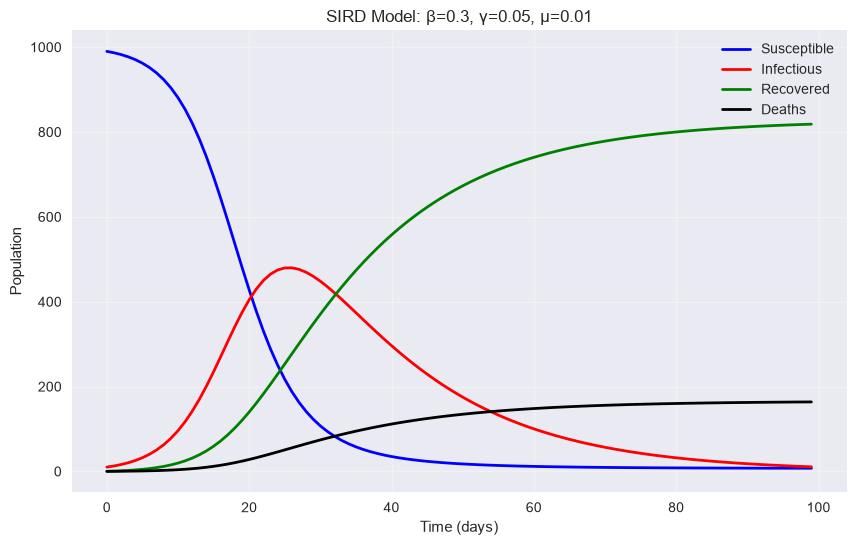

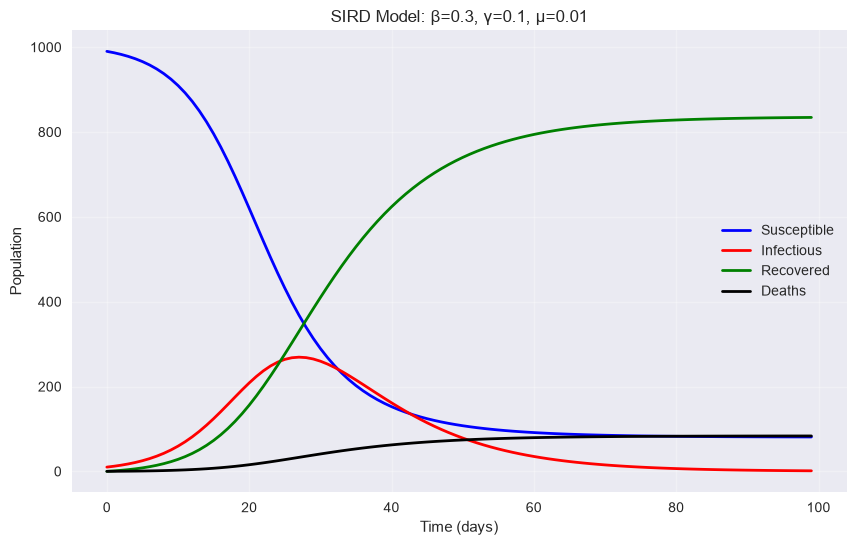

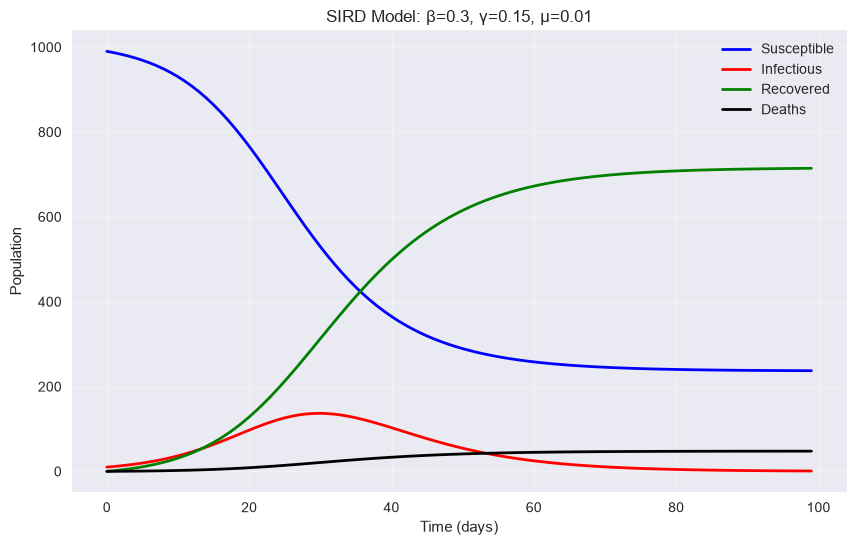

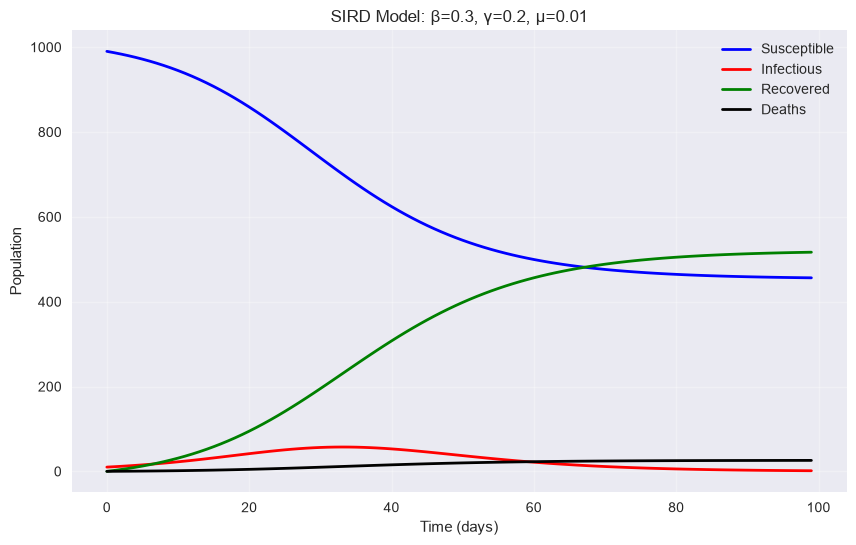

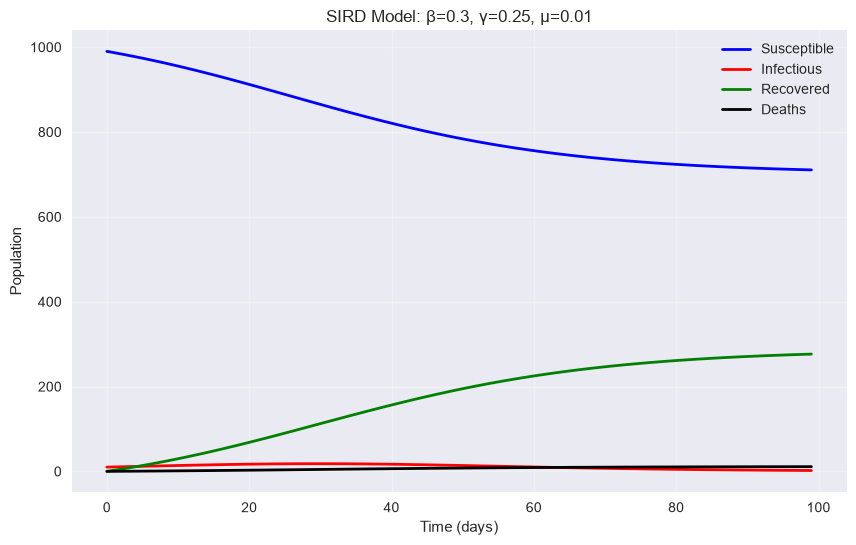

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0     479.737984      26.0    163.671765
1   0.10  3.0     269.138176      27.0     83.425371
2   0.15  2.0     136.756407      30.0     47.620529
3   0.20  1.5      57.359889      33.0     25.827702
4   0.25  1.2      18.021355      30.0     11.055013


In [7]:
# print the dataFrame
print(analyze_recovery_rates(0.3, 0.01, display_plots=True))

## Part 2


In [8]:
#Scenario A - "High Transmission":
scenario_a = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200, display_plots=False)
print(scenario_a)

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  8.000000     520.582635      21.0    284.757361
1   0.10  4.000000     340.140583      22.0    159.892366
2   0.15  2.666667     213.465894      24.0    102.610885
3   0.20  2.000000     123.893909      27.0     67.423926
4   0.25  1.600000      63.051893      30.0     42.694003


In [9]:
#Scenario B - "Low Transmission":
scenario_b = analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200, display_plots=False)
print(scenario_b)

   gamma        R0  peak_infected  peak_day  total_deaths
0   0.05  4.000000     371.356334      44.0     88.224137
1   0.10  2.000000     139.333450      52.0     36.699911
2   0.15  1.333333      31.340756      67.0     13.640017
3   0.20  1.000000       5.000000       0.0      1.831032
4   0.25  0.800000       5.000000       0.0      0.433166


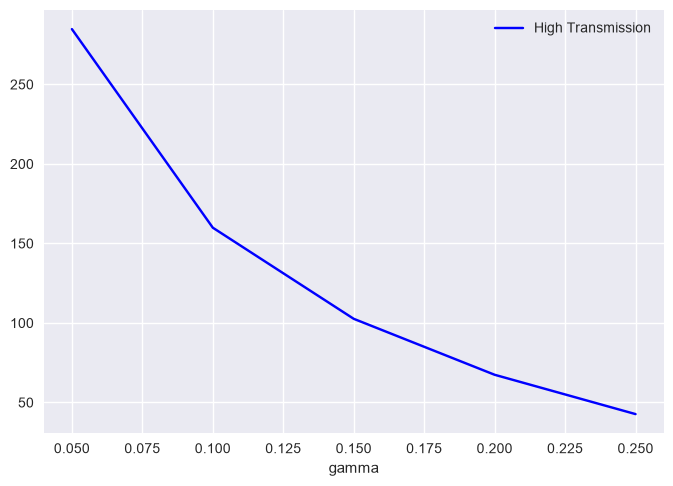

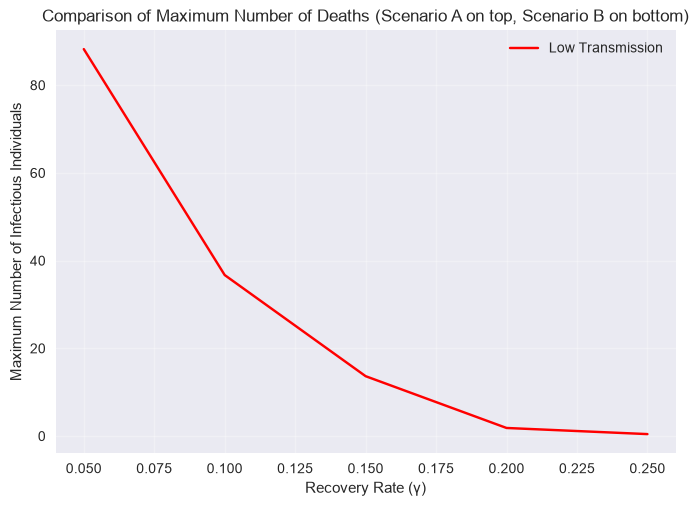

In [10]:
#Comparative side-by-side plot:
comb_plot = scenario_a.plot(x='gamma', y='total_deaths', label='High Transmission', color='blue')
comb_plot = scenario_b.plot(x='gamma', y='total_deaths', label='Low Transmission', color='red')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Maximum Number of Infectious Individuals')
plt.title('Comparison of Maximum Number of Deaths (Scenario A on top, Scenario B on bottom)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

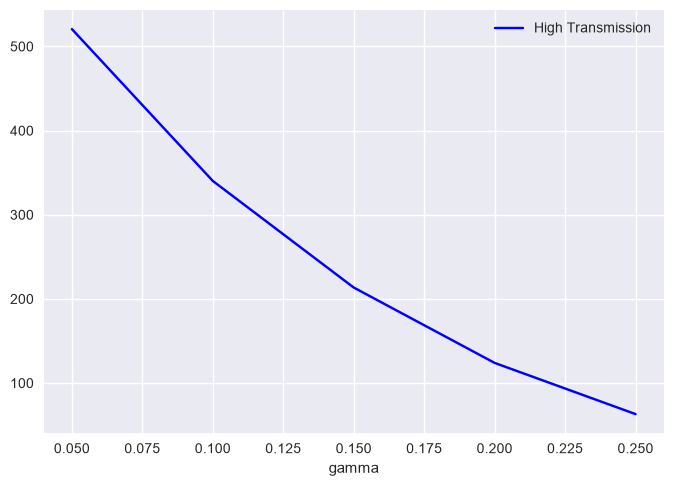

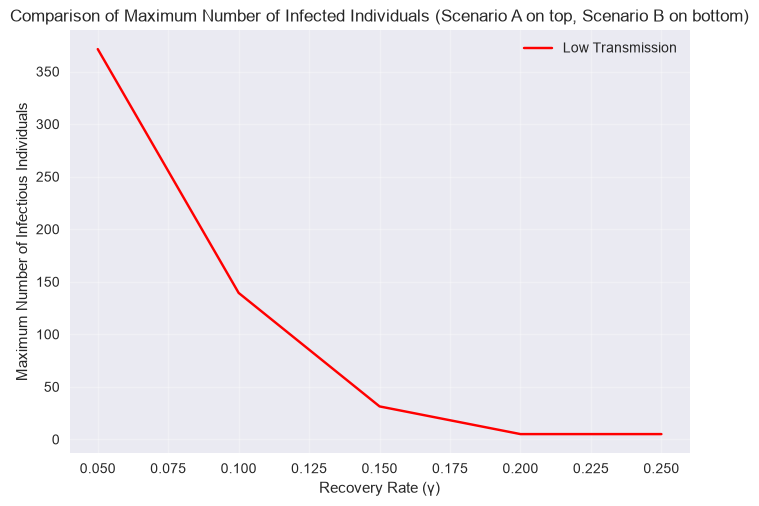

In [11]:
comb_plot = scenario_a.plot(x='gamma', y='peak_infected', label='High Transmission', color='blue')
comb_plot = scenario_b.plot(x='gamma', y='peak_infected', label='Low Transmission', color='red')
plt.xlabel('Recovery Rate (γ)')
plt.ylabel('Maximum Number of Infectious Individuals')
plt.title('Comparison of Maximum Number of Infected Individuals (Scenario A on top, Scenario B on bottom)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis:
As we can see on the plots, scenario B with lower transmission and mortality rates ultimately leads to less deaths, as well as less infected individuals.

DataFrames produced in both scenarios show a similar picture: lower transmission rate and mortality rate are a much better scenario for the public health.


## Part 3 — Policy Recommendations

### 3.1 Parameter impact analysis

## The results show that recovery rate has a large impact on the outcome of an epidemic. 

## For scenario A, there were major differences when the recovery rate value was changed. at when gamma is increased from 0.05 to 0.25, peak infected individuals goes form 521 to 63, total deaths reduce from 285 to 43 and the R0 score decreases from 8.0 to 1.6.

## similar results could be seen in scenario A, with the R0 score being as low as 0.8 at gamma=0.25, which is below the minimum for an epidemic to grow.

## There were also changes in the peak infection times with different recovery rates. Based on our results, as R0 decreases while staying above 1, the epidemic grows more slowly, which means it takes longer before there is a peak in infected people. at R0<=1, the peak is on day 0, as the number of infections does not grow.

## This gives us strong evidence that higher recovery rate can greatly reduce the impact/severity of an epidemic.

### 3.2 Intervention analysis

## We can use scenario A at γ=0.10 as. γnew=0.10*1.5=0.15 , which is also plotted.
## at γ=0.10, total deaths=156, and at γ=0.15, total deaths=102.61 (values/answers rounded to 2 d.p)
## reduction in deaths: 159.89-102.61=57.28
## 57.28/159.89=0.358 
## So increasing recovery rate by 50% reduces total deaths by about 35.8% in this scenario. this percentage can vary based on other variables such as death rate and transmission rate/how the disease is transmitted, but in general, increasing recovery rate will always reduce deaths, as individuals are not infected for as long, meaning they can't transmit the disease for as long.



### 3.3 Real-world application

## A real world intervention that increases recovery rate is the use of bacterial antibiotics to treat bacterial infections.
## Antibioitics prevent bacteria from growing/spreading. When the correct antibiotic is used against a bacterial infection, it helps clear the infection more quickly, and increases recovery rate. As mentioned earlier, this reduces severity of  an epidemic due to less overall time in the infectious department.
## The effect of antibiotics vary a lot depending on the type of infection and antibiotic used. There is also risk of potential resistance/immunity development to an antibiotic, so there is no exact percentage increase in recovery rate when bacterial antibiotics are used.

### 5. Conclusions
